In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 

In [7]:
titanic = sns.load_dataset("titanic")

In [10]:
titanic.head()
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
features = ["pclass","sex","fare","embarked","age"]
targate = ["survived"]

In [13]:
# missing vales

from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])


imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


In [15]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [22]:
#encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])




In [23]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [24]:
X = titanic[features]
y = titanic[targate]

In [36]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.3,random_state = 42
)

In [37]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [38]:
# desition tree - no pruning

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [39]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("accuracy :",accuracy_score(y_test,y_pred))

accuracy : 0.7686567164179104


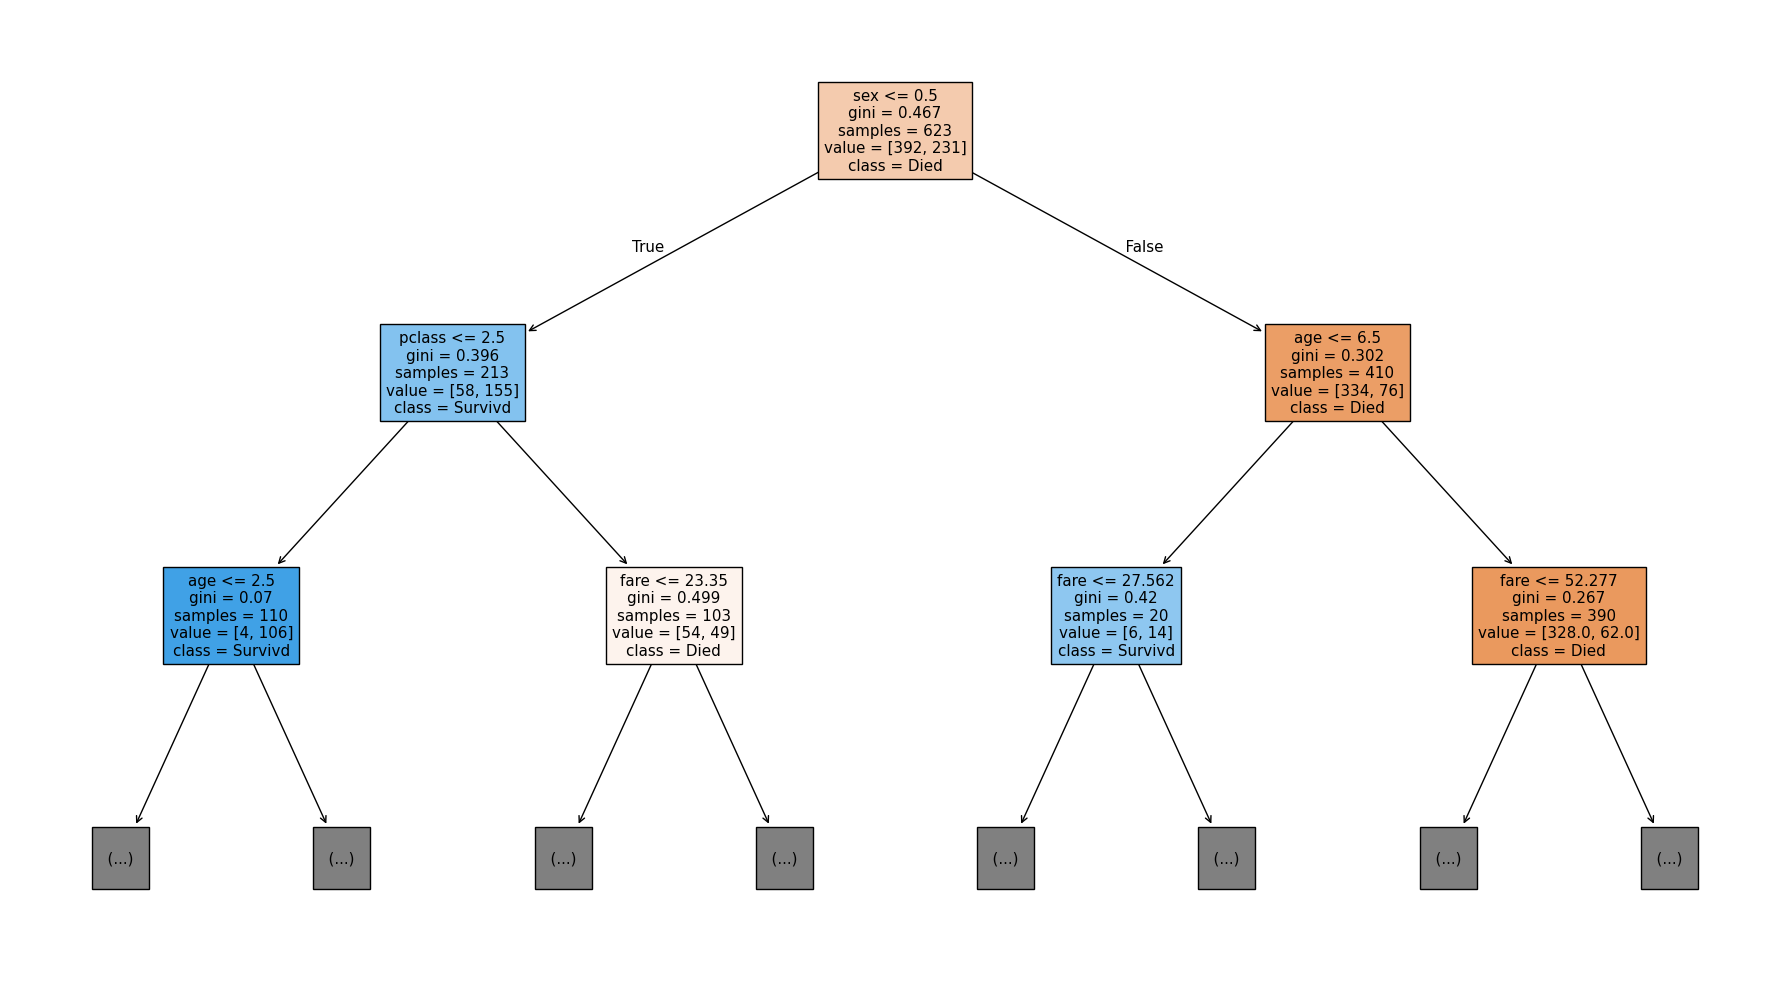

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names= ["Died","Survivd"],
    filled = True,
    max_depth = 2
)
plt.tight_layout()
plt.show()

# Decision Tree with pre pruning

depth : 2 , accuracy : 0.7723880597014925
depth : 3 , accuracy : 0.8059701492537313
depth : 4 , accuracy : 0.8246268656716418


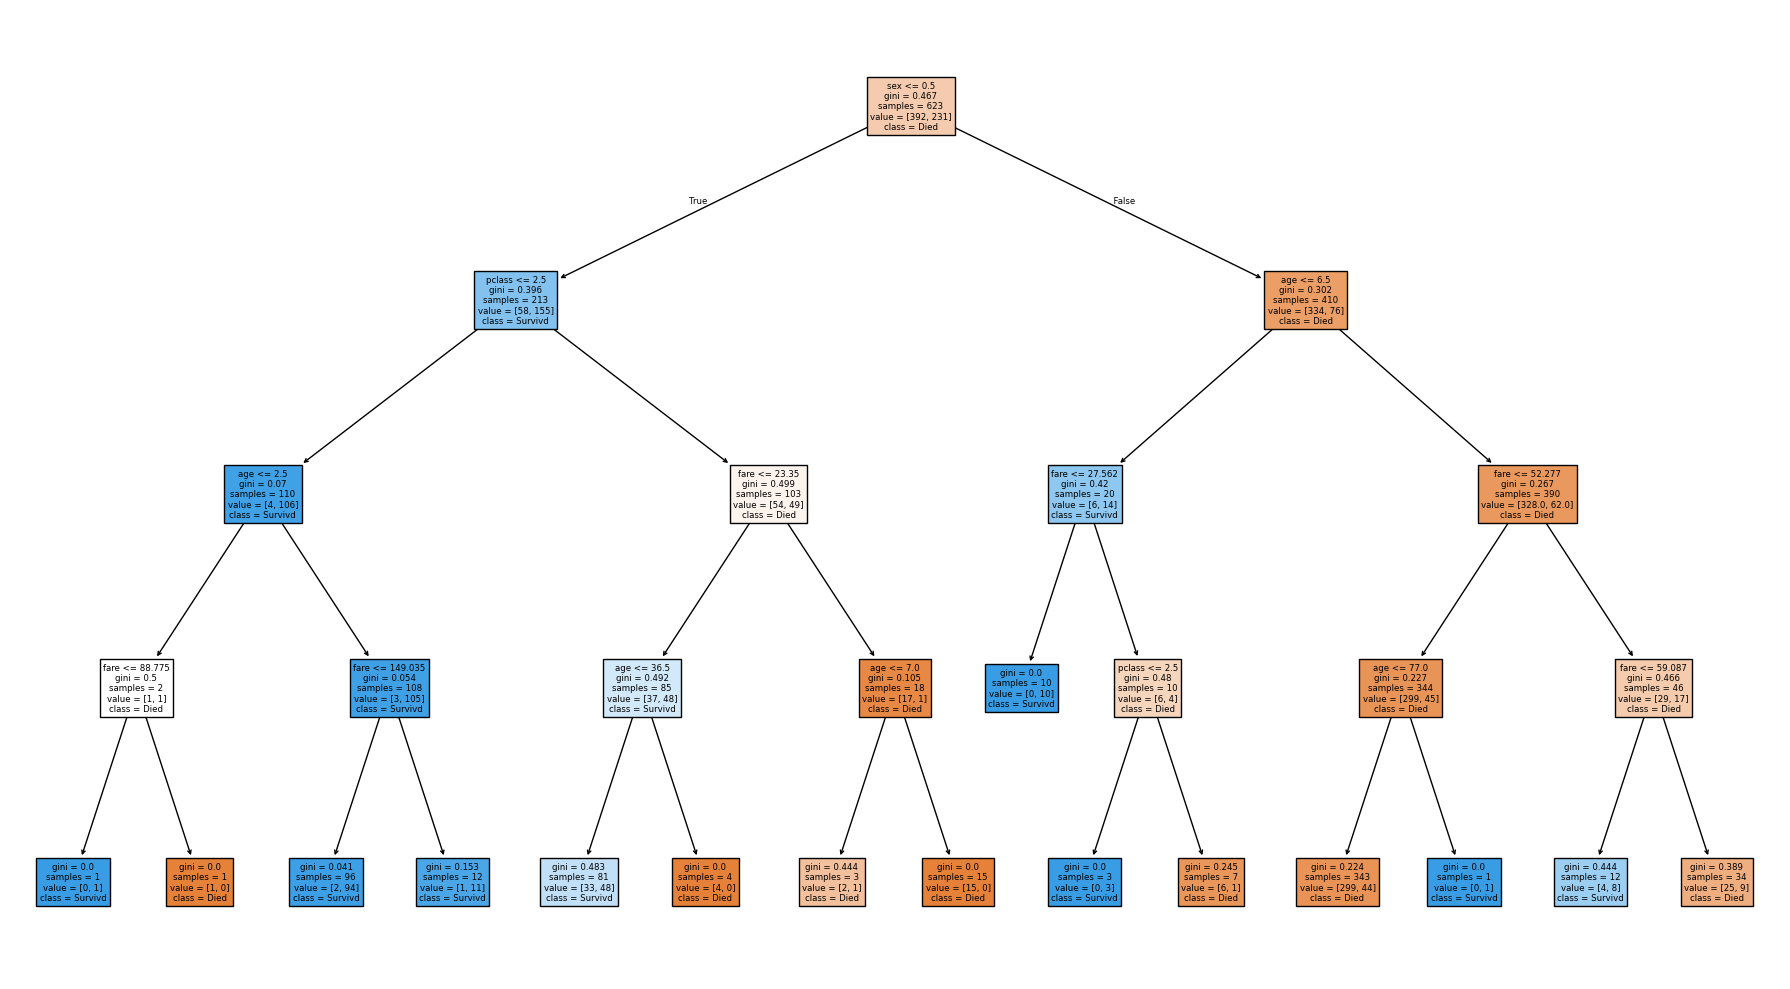

depth : 5 , accuracy : 0.7985074626865671
depth : 6 , accuracy : 0.7835820895522388
depth : 7 , accuracy : 0.7835820895522388
depth : 8 , accuracy : 0.7947761194029851
depth : 9 , accuracy : 0.7761194029850746
depth : 10 , accuracy : 0.7910447761194029


In [52]:
max_depth = [2,3,4,5,6,7,8,9,10]
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test)
    print(f"depth : {depth} , accuracy : {acc}")

    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names= ["Died","Survivd"],
            filled = True,
            
        )
        plt.tight_layout()
        plt.show()
        

sample split : 10 , accuracy : 0.8246268656716418


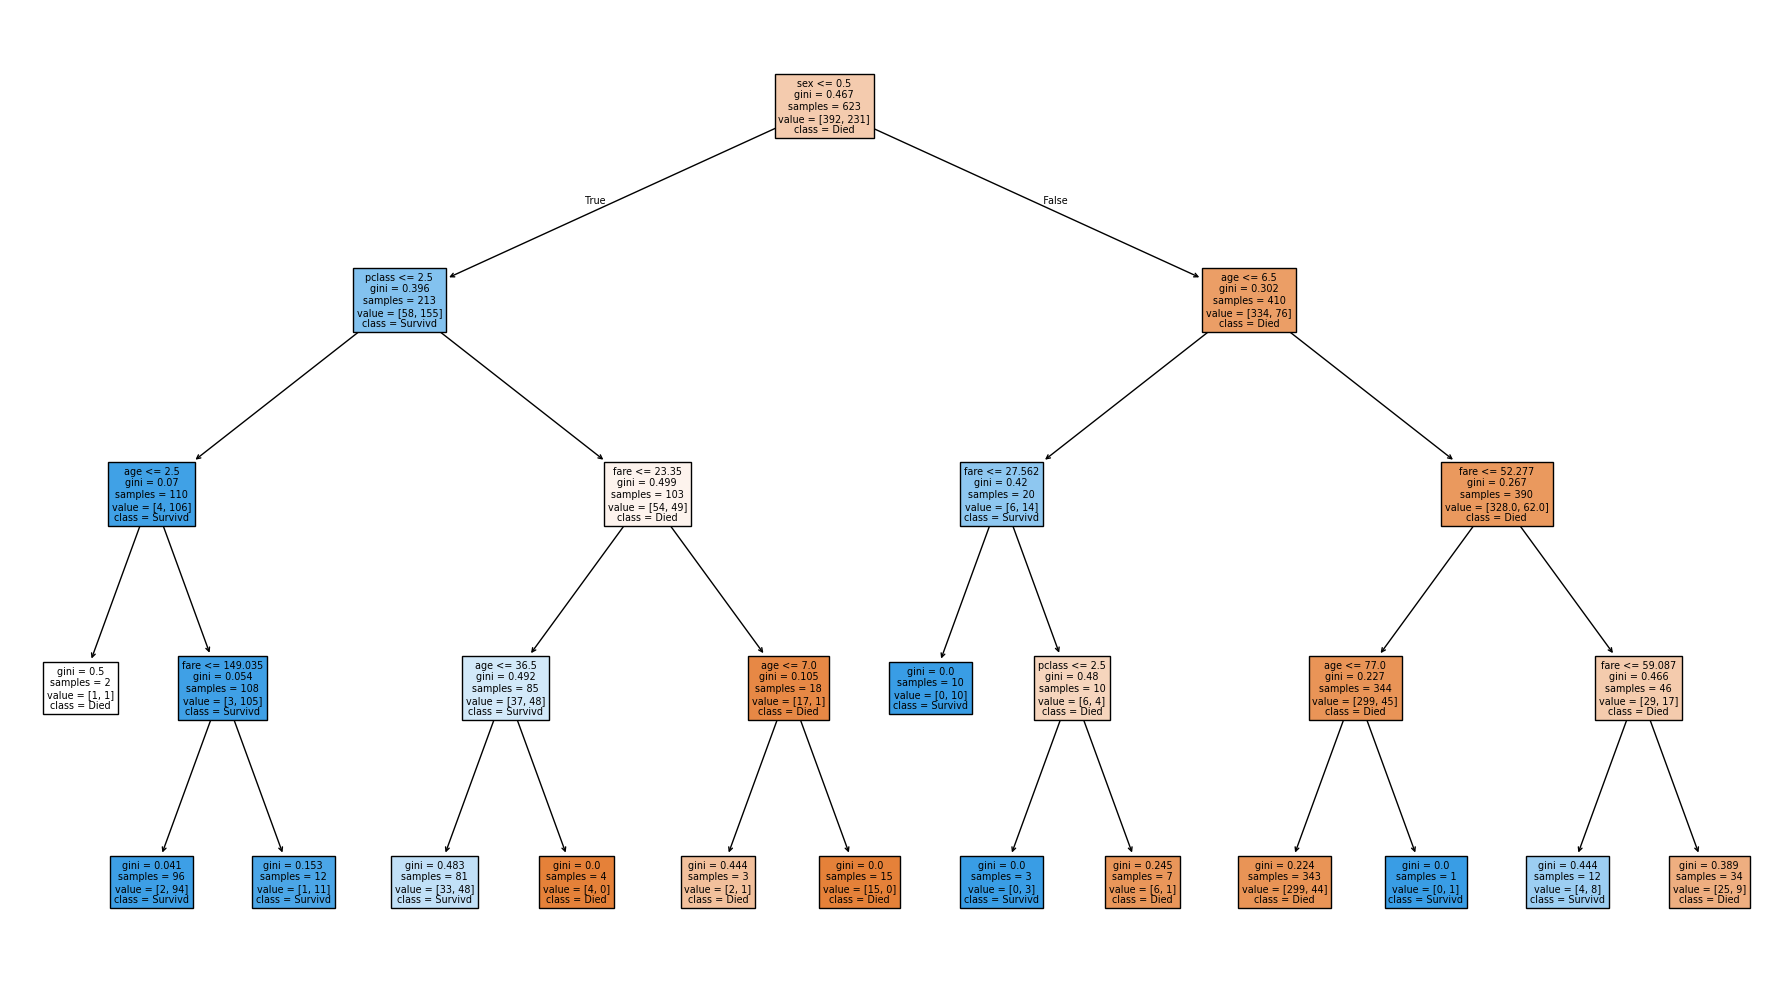

sample split : 15 , accuracy : 0.8171641791044776
sample split : 20 , accuracy : 0.8171641791044776
sample split : 25 , accuracy : 0.8208955223880597
sample split : 30 , accuracy : 0.8208955223880597


In [53]:
min_samples_split = [10,15,20,25,30]
for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split = split)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test)
    print(f"sample split : {split} , accuracy : {acc}")

    if split == 10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names= ["Died","Survivd"],
            filled = True,
            
        )
        plt.tight_layout()
        plt.show()
        

# Decision tree with post-pruning

In [55]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [58]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [70]:
# train our model for all alphas 
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha=alpha)
    model.fit(X_train,y_train)

    trees.append((model, alpha))

In [71]:
best_acc = 0
best_alpha = 0

for model,alpha in trees:
    
    curr_acc = model.score(X_test,y_test)
    if curr_acc >best_acc:
        best_acc = curr_acc
        best_alpha = alpha


In [72]:
best_alpha

np.float64(0.0017121455323702516)

In [73]:
best_acc 

0.8208955223880597

In [78]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha,max_depth =4)
best_model.fit(X_train,y_train)


DecisionTreeClassifier(ccp_alpha=np.float64(0.0017121455323702516), max_depth=4)

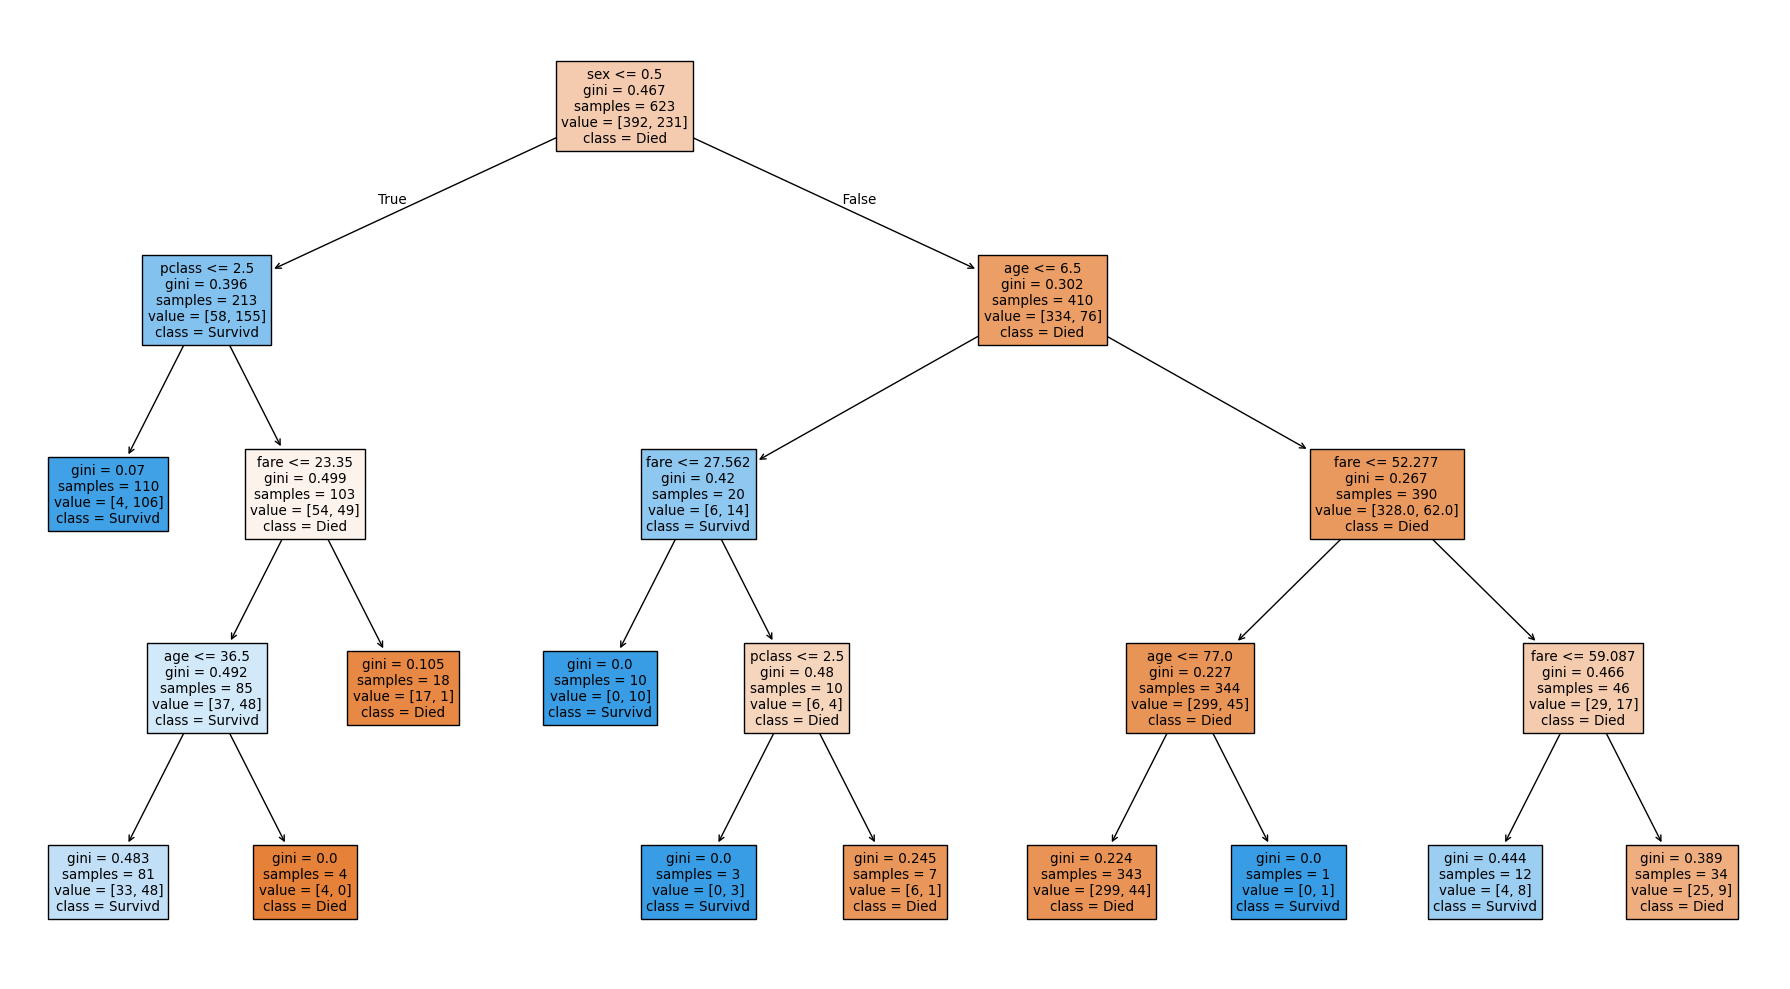

In [79]:
plt.figure(figsize=(18,10))
plot_tree(
best_model,
feature_names = X.columns,
class_names= ["Died","Survivd"],
filled = True,
            
)
plt.tight_layout()
plt.show()
        

In [81]:
print(best_model.score(X_test,y_test))

0.8246268656716418
